In [2]:
# Install the latest Ultralytics library
!pip install ultralytics
!pip install roboflow
import torch
from ultralytics import YOLO

# Verify GPU availability
print(f"Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Using device: CPU


In [3]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="6BezSMC6wWscvbI535Zu")
project = rf.workspace("laundry").project("volleyball-lcy2z")
dataset = project.version(2).download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to volleyball-2 in yolo26:: 100%|██████████| 8337/8337 [00:03<00:00, 2101.13it/s]


In [4]:
import os
HOME = os.getcwd()
print(HOME)

/Users/kai-chengliu/Desktop/Volley-Vision


In [5]:
from ultralytics import YOLO

# Load the new YOLO26 model
model = YOLO('yolo26n.pt')

# Train with valid arguments
# model.train(
#     data=f"{dataset.location}/data.yaml",
#     epochs=100,
#     imgsz=640,
#     optimizer='MuSGD', # Optimized for YOLO26
#     plots=True         # Generates the charts to see your progress
# )

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640,
    optimizer='MuSGD',
    # --- NEW PARAMETERS ---
    patience=20,      # Early stopping: stops if no improvement for 20 epochs
    batch=16,         # Adjust based on your GPU memory (e.g., 16, 32, or -1 for auto)
    save_period=10,   # Saves a checkpoint every 10 epochs (safety backup)
    cos_lr = True,
    # --- VOLLEYBALL TUNING ---
    mosaic=1.0,       # Excellent for small objects like balls
    mixup=0.2,        # Helps model handle overlapping objects (net/players)
    overlap_mask=True # Good if you later move to segmentation
)

New https://pypi.org/project/ultralytics/8.4.40 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.38 🚀 Python-3.12.4 torch-2.9.1 CPU (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/kai-chengliu/Desktop/Volley-Vision/volleyball-2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scal

KeyboardInterrupt: 

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

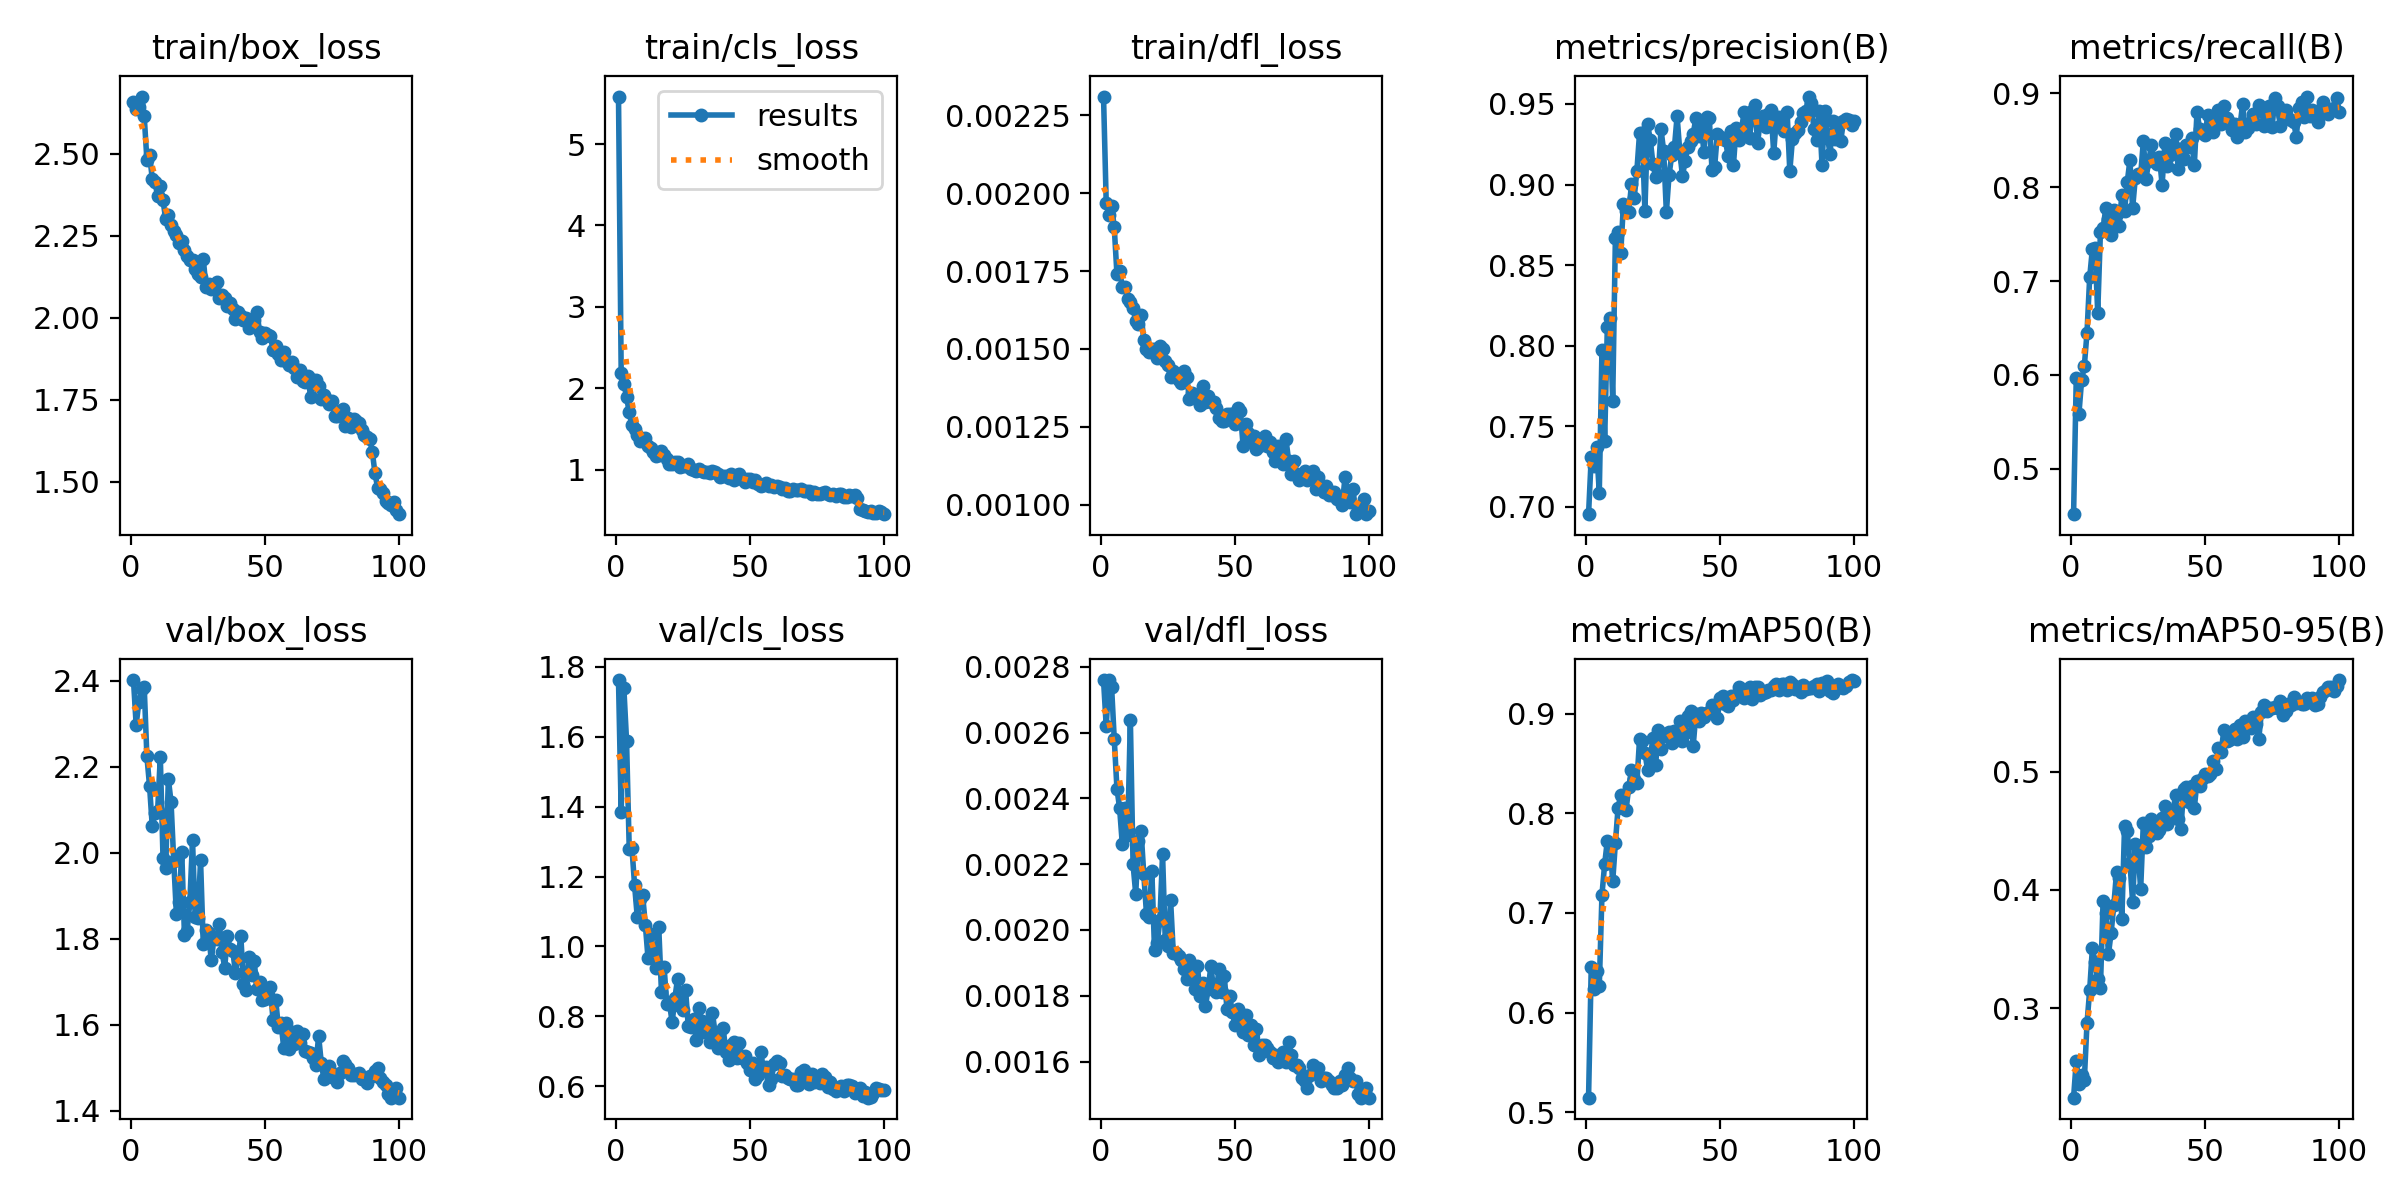

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

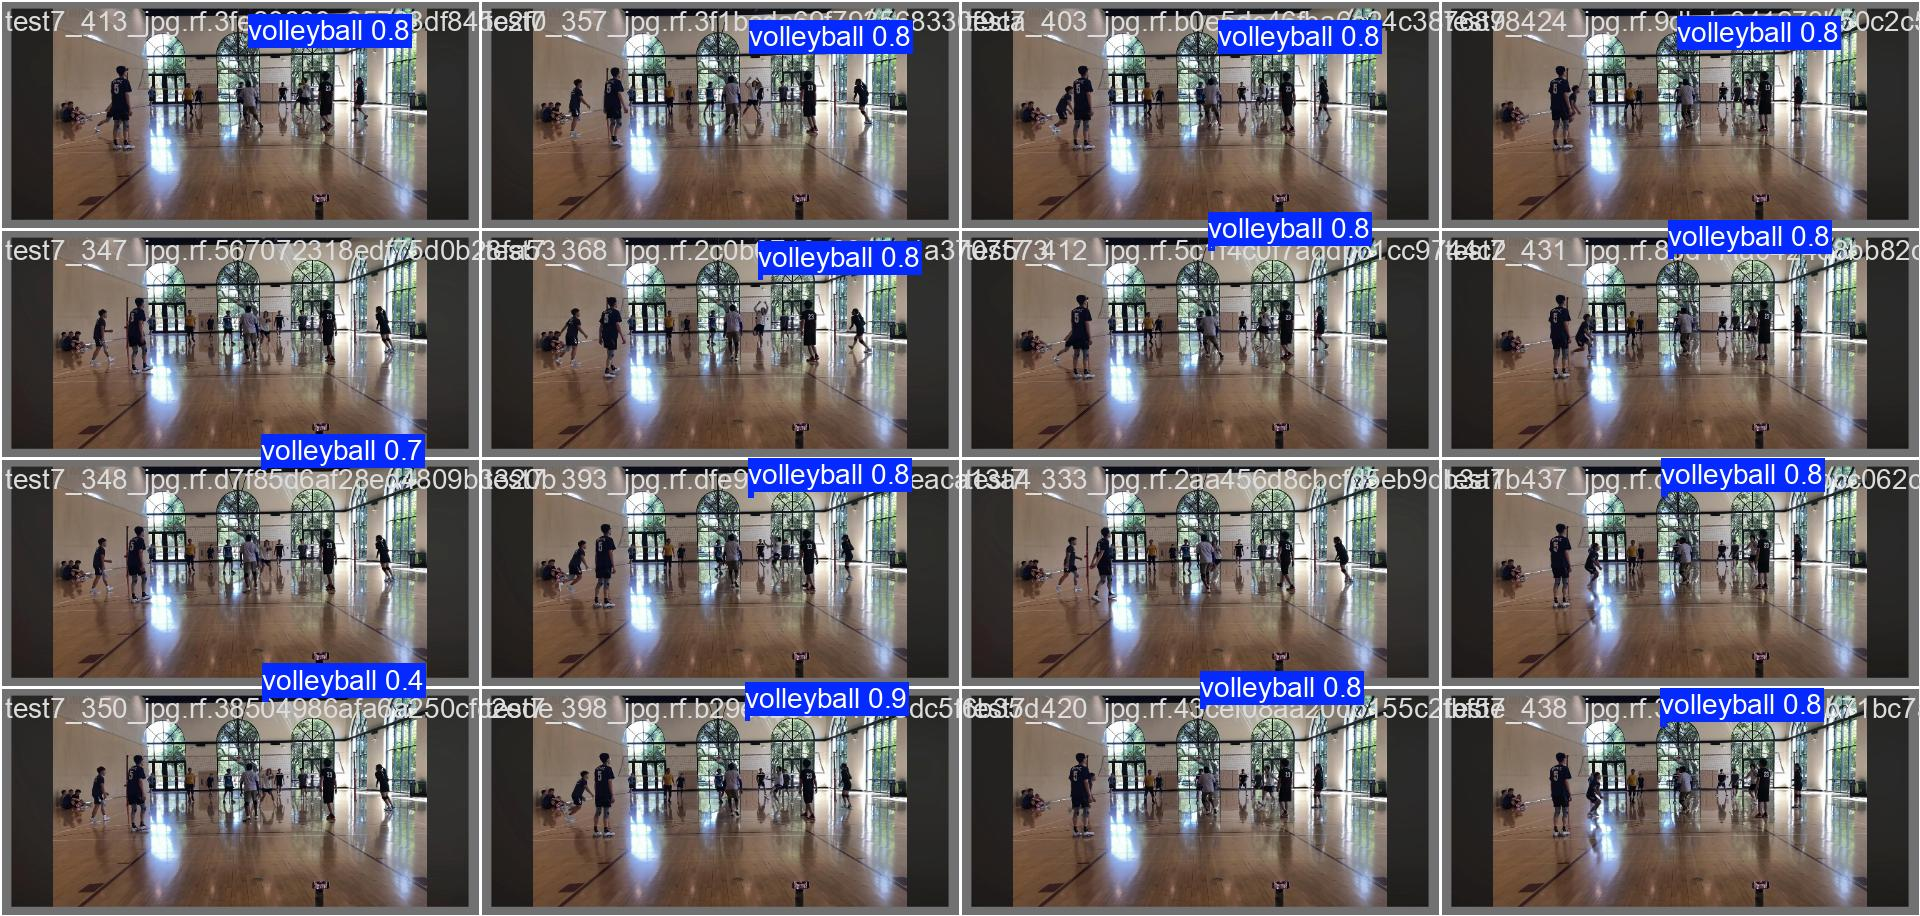

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [ ]:
from ultralytics import YOLO

# 1. Load your best custom weights (make sure the path matches your run name)
# If you didn't name your run, it usually defaults to 'train' or 'train2'
custom_model = YOLO('/content/runs/detect/train/weights/best.pt')

# 2. Run validation on the validation/test split of your dataset
print("Starting validation...")
metrics = custom_model.val()

# 3. Print out the specific scores you care about for tracking
print(f"Mean Average Precision (mAP50): {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f} (How often it's right when it says 'Ball!')")
print(f"Recall: {metrics.box.mr:.4f} (How many of the actual balls it successfully found)")

Starting validation...
Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3677.0±962.8 MB/s, size: 263.3 KB)
val: Scanning /content/volleyball-1/valid/labels.cache... 709 images, 235 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 709/709 247.8Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 323, len(boxes) = 476. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 3.8it/s 11.8s
                   all        709        476      0.926      0.893      0.933      0.579
Speed: 1.2ms preprocess, 3.9ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved t

In [ ]:
from google.colab import files

# Download your customized weights
files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

# Load your newly trained VolleyVision model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Run prediction on a new test video
results = model.predict(
    stream=True,     # Stream video frames
    source='test12.mov',
    save=True,       # Saves a new video with boxes drawn on it
    conf=0.4,        # Only draw a box if it's 40%+ confident
    line_width=2     # Thinner lines look better on small objects like balls
)

print("Check the /runs/detect/predict/ folder for your output video!")


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/564) /content/test12.mov: 320x640 (no detections), 59.8ms
video 1/1 (frame 2/564) /content/test12.mov: 320x640 (no detections), 11.8ms
video 1/1 (frame 3/564) /content/test12.mov: 320x640 (no detections), 14.7ms
video 1/1 (frame 4/564) /content/test12.mov: 320x640 (no detections), 13.1ms
video 1/1 (frame 5/564) /content/test12.mov: 320x640 1 volleyball, 13.4ms
video 1/1 (frame 6/564) /content/test12.mov: 320x640 1 volleyball, 10.5ms
vi

### SDK

In [ ]:
from ultralytics import YOLO

model = YOLO(f'{HOME}/runs/detect/train/weights/best.pt')

In [ ]:
!pip install supervision
import supervision as sv

ds_test = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 25.7 MB/s eta 0:00:00


In [ ]:
import supervision as sv
from PIL import Image

def annotate(image: Image.Image, detections: sv.Detections) -> Image.Image:
    color = sv.ColorPalette.from_hex([
        "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00",
        "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    ])

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    box_annotator = sv.BoxAnnotator(color=color)
    label_annotator = sv.LabelAnnotator(
        color=color,
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        smart_position=True
    )

    out = image.copy()
    out = box_annotator.annotate(out, detections)
    out = label_annotator.annotate(out, detections)
    out.thumbnail((1000, 1000))
    return out

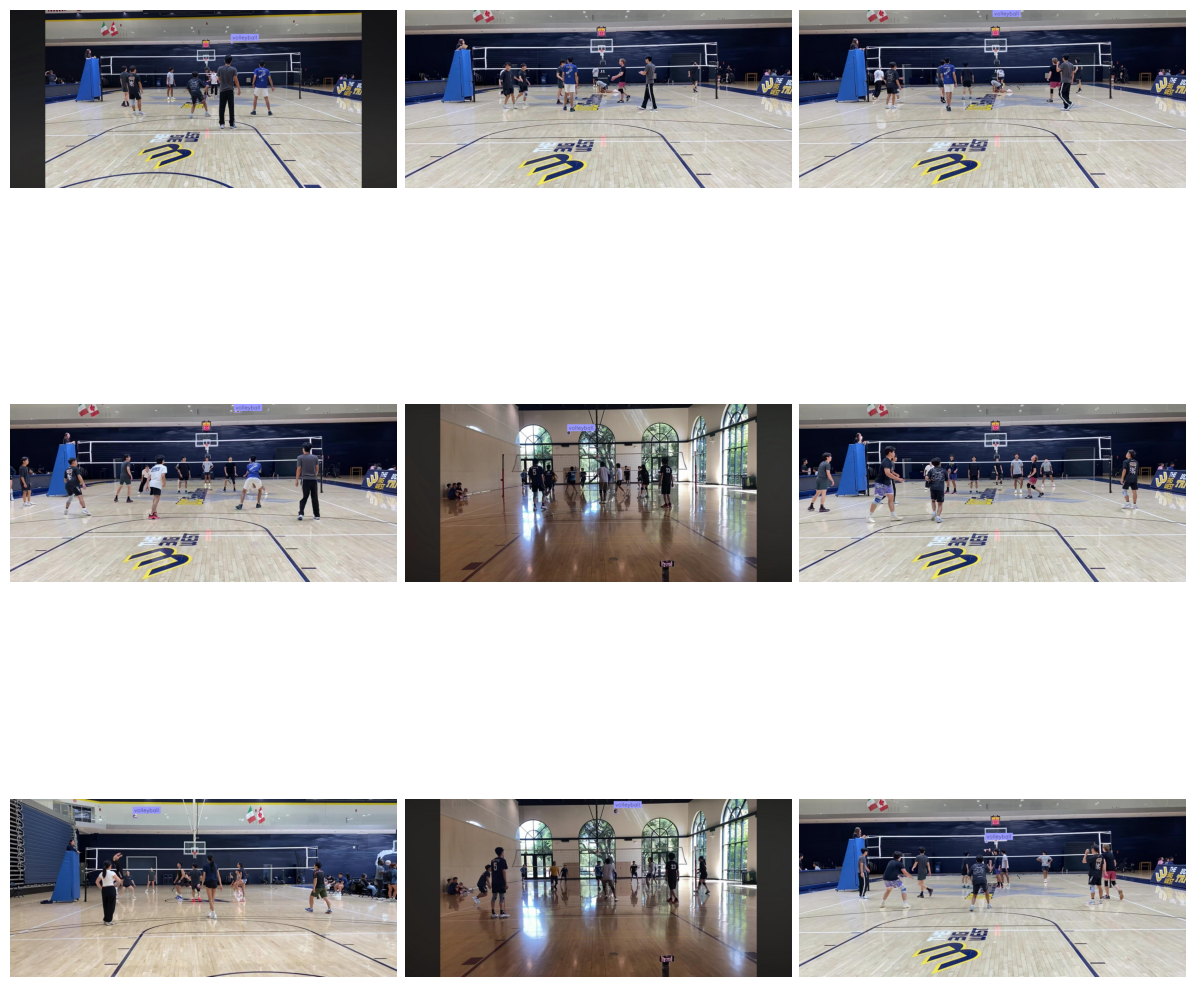

In [ ]:
import random
import matplotlib.pyplot as plt

N = 9
L = len(ds_test)

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds_test[i]
    image = Image.open(path)
    result = model.predict(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    annotated_image = annotate(image, detections)
    annotated_images.append(annotated_image)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)

plt.show()

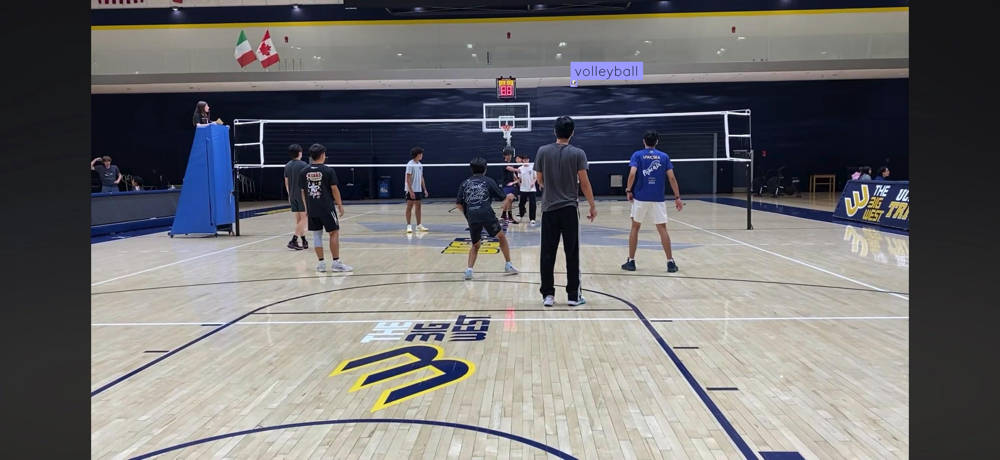

In [ ]:
annotated_images[0]